# Phase 4 — Inventory EDA

Stock levels, stockouts, excess inventory, turnover, and warehouse performance. All figures here come from the synthetic `fact_inventory` simulation (`etl/synthesize/inventory.py`) — `sold_quantity` is real, aggregated `fact_sales`; the stock-level bookkeeping is simulated. Scoped to the top 500 products by volume (see that module's docstring).

**Prerequisite:** `make etl` has been run and `DATABASE_URL` points at the populated warehouse.

In [1]:
import sys
from pathlib import Path

sys.path.append(str(Path.cwd().parent))

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from src.eda import data_access

sns.set_theme(style="whitegrid")
pd.set_option("display.float_format", lambda v: f"{v:,.2f}")


In [2]:
inventory = data_access.load_inventory_detail()
inventory.shape

(181903, 11)

## 1. Stock levels

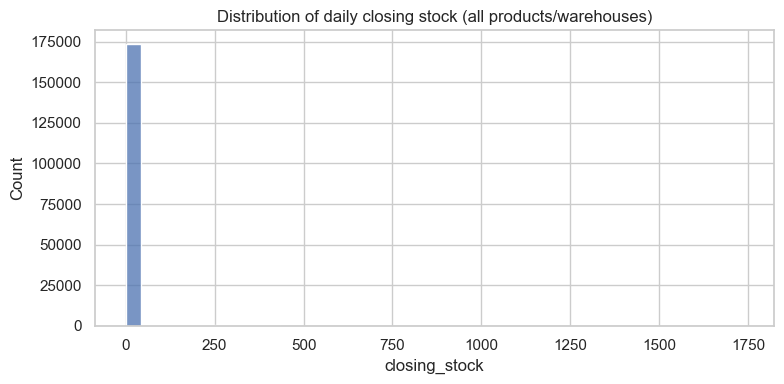

In [3]:
fig, ax = plt.subplots(figsize=(8, 4))
sns.histplot(inventory['closing_stock'], bins=40, ax=ax)
ax.set_title('Distribution of daily closing stock (all products/warehouses)')
plt.tight_layout()
plt.show()

## 2. Stockouts

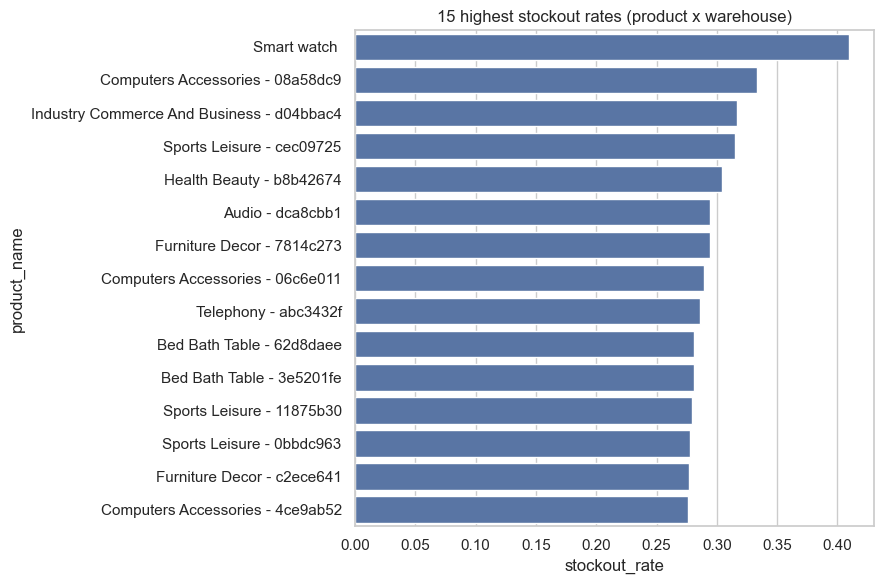

In [4]:
stockout_freq = data_access.run_sql_file('03_inventory/02_stockout_frequency_by_product.sql')
top_stockouts = stockout_freq.sort_values('stockout_rate', ascending=False).head(15)

fig, ax = plt.subplots(figsize=(9, 6))
sns.barplot(data=top_stockouts, x='stockout_rate', y='product_name', ax=ax)
ax.set_title('15 highest stockout rates (product x warehouse)')
plt.tight_layout()
plt.show()

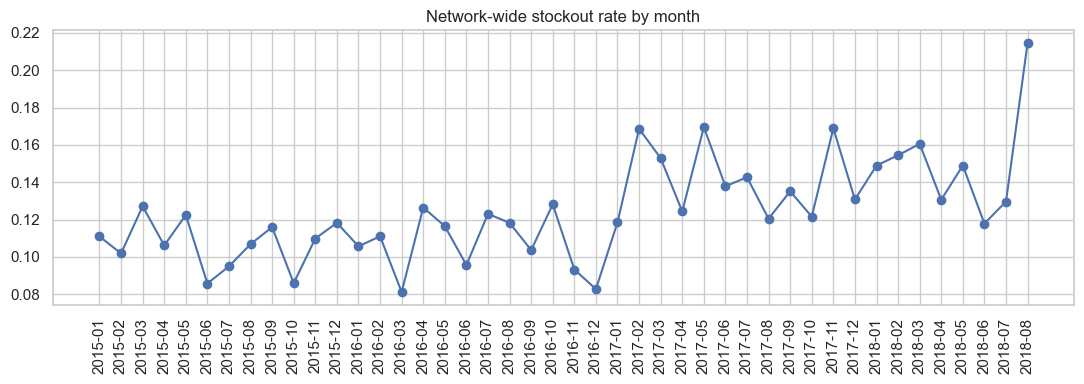

In [5]:
stockout_trend = data_access.run_sql_file('03_inventory/12_stockout_days_filter.sql')
stockout_trend['period'] = (
    stockout_trend['year'].astype(str) + '-' + stockout_trend['month'].astype(str).str.zfill(2)
)
fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(stockout_trend['period'], stockout_trend['stockout_rate'], marker='o')
ax.set_title('Network-wide stockout rate by month')
ax.tick_params(axis='x', rotation=90)
plt.tight_layout()
plt.show()

## 3. Excess inventory

Defined here as **days of supply > 45** (average closing stock / average daily demand) — a product sitting on ~1.5 months of stock or more, a common inventory-management rule of thumb, not derived from the data itself (a stated threshold, not a discovered one).

13 of 502 tracked products show >45 days of supply


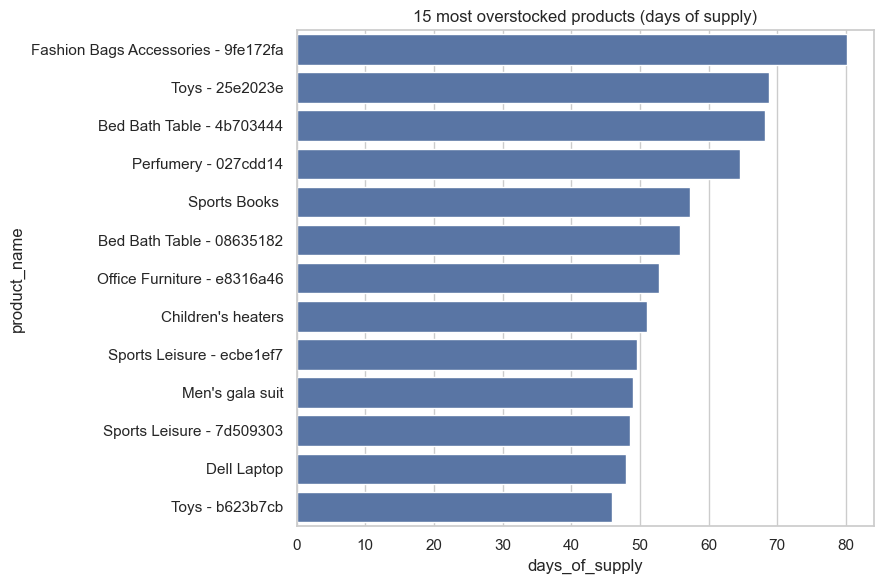

In [6]:
product_stats = inventory.groupby(['product_source_id', 'product_name']).agg(
    avg_closing_stock=('closing_stock', 'mean'),
    avg_daily_demand=('sold_quantity', 'mean'),
).reset_index()
product_stats = product_stats[product_stats['avg_daily_demand'] > 0]
product_stats['days_of_supply'] = (
    product_stats['avg_closing_stock'] / product_stats['avg_daily_demand']
)
excess = product_stats[product_stats['days_of_supply'] > 45].sort_values(
    'days_of_supply', ascending=False
)
print(f'{len(excess)} of {len(product_stats)} tracked products show >45 days of supply')

fig, ax = plt.subplots(figsize=(9, 6))
sns.barplot(data=excess.head(15), x='days_of_supply', y='product_name', ax=ax)
ax.set_title('15 most overstocked products (days of supply)')
plt.tight_layout()
plt.show()

## 4. Turnover

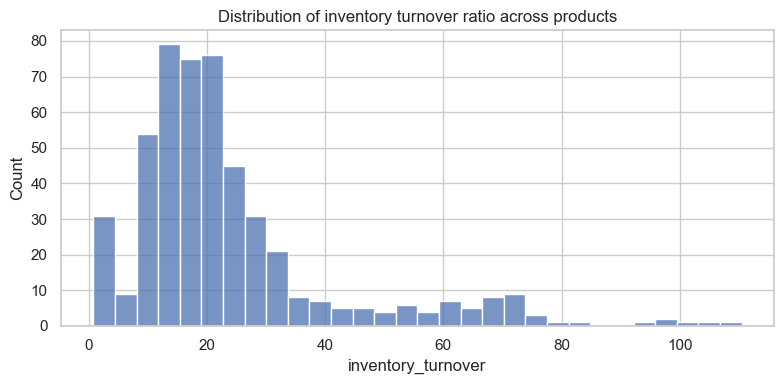

,product_name,total_cogs,avg_inventory_value,inventory_turnover
0,Diamondback Women's Serene Classic Comfort Bi,"11,943,406.26","108,102.15",110.48
1,Pelican Sunstream 100 Kayak,"7,634,370.00","72,078.04",105.92
2,O'Brien Men's Neoprene Life Vest,"7,102,832.64","69,209.53",102.63
3,Nike Men's Dri-FIT Victory Golf Polo,"9,495,023.92","95,672.35",99.25
4,Field & Stream Sportsman 16 Gun Fire Safe,"14,640,491.25","148,389.44",98.66
5,Perfect Fitness Perfect Rip Deck,"13,589,174.22","142,656.82",95.26
6,Glove It Women's Mod Oval Golf Glove,"36,098.02",437.21,82.57
7,Top Flite Women's 2014 XL Hybrid,"48,802.74",605.45,80.61
8,Titleist Pro V1x High Numbers Golf Balls,"78,080.00","1,010.57",77.26
9,Bridgestone e6 Straight Distance NFL San Dieg,"58,944.36",763.88,77.16


In [7]:
turnover = data_access.run_sql_file('03_inventory/03_inventory_turnover_by_product.sql')
fig, ax = plt.subplots(figsize=(8, 4))
sns.histplot(turnover['inventory_turnover'].dropna(), bins=30, ax=ax)
ax.set_title('Distribution of inventory turnover ratio across products')
plt.tight_layout()
plt.show()
turnover.sort_values('inventory_turnover', ascending=False).head(10)

## 5. Warehouse performance

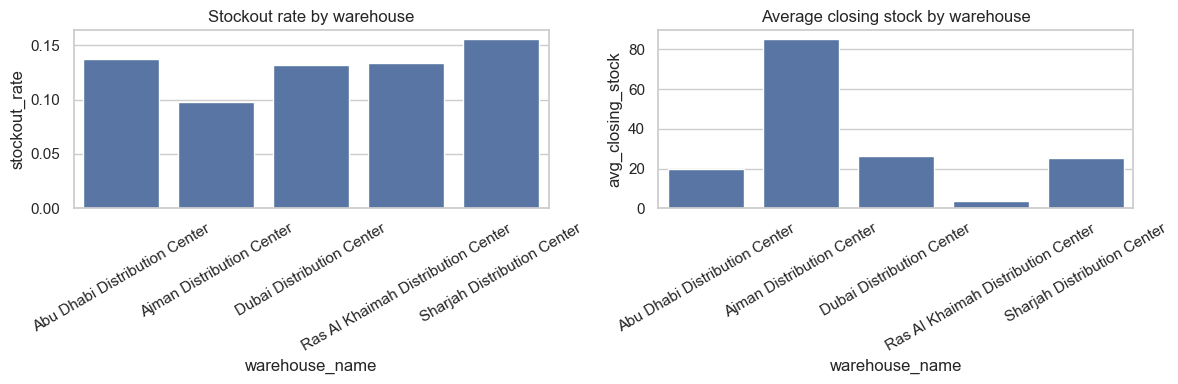

,warehouse_name,avg_closing_stock,stockout_rate,avg_sold_quantity
0,Abu Dhabi Distribution Center,19.65,0.14,1.53
1,Ajman Distribution Center,85.21,0.10,6.99
2,Dubai Distribution Center,26.25,0.13,1.93
3,Ras Al Khaimah Distribution Center,3.82,0.13,0.18
4,Sharjah Distribution Center,25.07,0.16,1.63


In [8]:
by_warehouse = inventory.groupby('warehouse_name').apply(
    lambda g: pd.Series({
        'avg_closing_stock': g['closing_stock'].mean(),
        'stockout_rate': (g['closing_stock'] == 0).mean(),
        'avg_sold_quantity': g['sold_quantity'].mean(),
    }),
    include_groups=False,
).reset_index()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.barplot(data=by_warehouse, x='warehouse_name', y='stockout_rate', ax=axes[0])
axes[0].set_title('Stockout rate by warehouse')
axes[0].tick_params(axis='x', rotation=30)
sns.barplot(data=by_warehouse, x='warehouse_name', y='avg_closing_stock', ax=axes[1])
axes[1].set_title('Average closing stock by warehouse')
axes[1].tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.show()
by_warehouse